In [ ]:
##hallo 

In [1]:
import numpy as np
import pandas as pd

df_1 = "/Users/lukasstraehnz/code/lukasst00-code/climate_trace_emissions_tool/climate_trace_emission_tool/raw_data/combined.csv"

df_1 = pd.read_csv(df_1, low_memory=False)

df_1

,Unnamed: 0,source_id,source_name,source_type,iso3_country,sector,subsector,start_time,end_time,lat,...,other7,other7_def,other8,other8_def,other9,other9_def,other10,other10_def,created_date,modified_date
0,0,42979340,Aruba,NaN,ABW,agriculture,crop-residues,2026-04-01,2026-04-30 00:00:00,12.530011,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-08-06 00:00:00,2026-06-07 09:40:02.534952
1,1,42139086,Ab Band District,NaN,AFG,agriculture,crop-residues,2026-04-01,2026-04-30 00:00:00,32.898943,...,0.0003458046412823,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-06-04 00:00:00,2026-06-07 09:40:02.534952
2,2,42139021,Ab Kamari District,NaN,AFG,agriculture,crop-residues,2026-04-01,2026-04-30 00:00:00,35.064700,...,0.0003468568485436,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-06-04 00:00:00,2026-06-07 09:40:02.534952
3,3,42139220,Achin District,NaN,AFG,agriculture,crop-residues,2026-04-01,2026-04-30 00:00:00,34.057137,...,0.0003457881511768,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-06-04 00:00:00,2026-06-07 09:40:02.534952
4,4,42139121,Adraskan District,NaN,AFG,agriculture,crop-residues,2026-04-01,2026-04-30 00:00:00,33.736256,...,0.0003471798915056,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2025-06-04 00:00:00,2026-06-07 09:40:02.534952
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1817010,1817010,46011136,OpenStreetMap Landfill,Dumpsite,ZAF,waste,solid-waste-disposal,2026-04-01,2026-04-30 00:00:00,-25.736398,...,False,Present landfill gas collection system,unknown,Landfill cover type,16339.187366762637,Original reported annual incoming waste,0.0108437502355327,Original reported waste in place,2026-05-29 00:00:00,2026-06-07 07:23:45.794023
1817011,1817011,46011137,OpenStreetMap Landfill,Dumpsite,ZAF,waste,solid-waste-disposal,2026-04-01,2026-04-30 00:00:00,-25.941398,...,False,Present landfill gas collection system,unknown,Landfill cover type,15258.702515019488,Original reported annual incoming waste,0.0107152373300789,Original reported waste in place,2026-05-29 00:00:00,2026-06-07 07:23:45.794023
1817012,1817012,51118103,OpenStreetMap Landfill,Dumpsite,ZAF,waste,solid-waste-disposal,2026-04-01,2026-04-30 00:00:00,-26.190146,...,False,Present landfill gas collection system,unknown,Landfill cover type,56507.02723007195,Original reported annual incoming waste,0.0106923085770612,Original reported waste in place,2026-05-29 00:00:00,2026-06-07 07:23:45.794023
1817013,1817013,46009601,Chunga,Sanitary Landfill,ZMB,waste,solid-waste-disposal,2026-04-01,2026-04-30 00:00:00,-15.349024,...,False,Present landfill gas collection system,unknown,Landfill cover type,8960.827875860077,Original reported annual incoming waste,0.0173352798094326,Original reported waste in place,2026-05-29 00:00:00,2026-06-07 07:23:45.794023


In [26]:
import pandas as pd

# Keep only relevant columns
df = df_1[['emissions_factor', 'activity', 'subsector']].copy()

# Remove missing values
df = df.dropna()
df_1 = df_1[df_1["emissions_factor"] <= 1000].copy()
df_1 = df_1[df_1["emissions_factor"] != 0].copy()
df_1 = df_1[df_1["activity"] != 0].copy()
# Check
df.head()

,emissions_factor,activity,subsector
0,0.410818,0.00000,crop-residues
1,0.416304,62.66544,crop-residues
2,0.419134,16.23148,crop-residues
3,0.414245,18.10357,crop-residues
4,0.417891,77.59666,crop-residues


In [27]:
from sklearn.model_selection import train_test_split

X = df[['activity', 'subsector']]
y = df['emissions_factor']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [28]:
df_1.isnull().sum().sort_values(ascending=False)

other10_def               746084
geometry_ref              716274
other10                   576357
other9_def                559974
other8_def                552959
other4                    520483
other8                    479768
source_type               460914
other9                    418495
other6_def                400199
other5_def                341247
other4_def                341247
other7_def                341247
other5                    255910
other6                    253908
other7                    250768
other3_def                198850
other2                    188782
other2_def                185950
other1_def                184963
other1                    167608
other3                    119118
lon                        73346
lat                        73346
created_date                   0
Unnamed: 0                     0
source_id                      0
capacity_factor                0
source_name                    0
iso3_country                   0
sector    

In [29]:
from sklearn.model_selection import train_test_split

X = df[['activity', 'subsector']]
y = df['emissions_factor']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [30]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

categorical_features = ['subsector']
numeric_features = ['activity']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features),
        ('num', 'passthrough', numeric_features)
    ]
)

In [31]:
from sklearn.linear_model import LinearRegression

model = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['subsector']),
                                                 ('num', 'passthrough',
                                                  ['activity'])])),
                ('regressor', LinearRegression())])

In [32]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    X,
    y,
    cv=5,
    scoring='r2'
)

print("Mean R²:", scores.mean())
print(scores)

Mean R²: -1.26922476984083
[-1.38665594e+00 -1.49988511e+00 -3.35179705e+00 -1.07805727e-01
  1.99693102e-05]


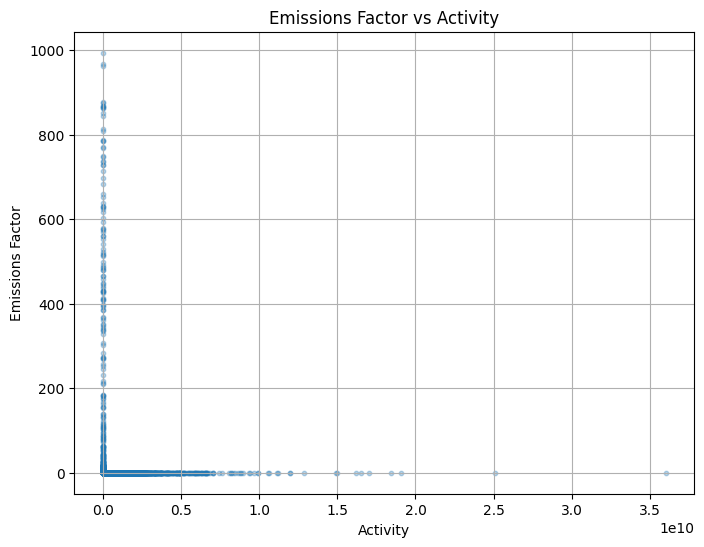

In [33]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
plt.scatter(
    df_1["activity"],
    df_1["emissions_factor"],
    alpha=0.3,
    s=10
)

plt.xlabel("Activity")
plt.ylabel("Emissions Factor")
plt.title("Emissions Factor vs Activity")
plt.grid(True)

plt.show()

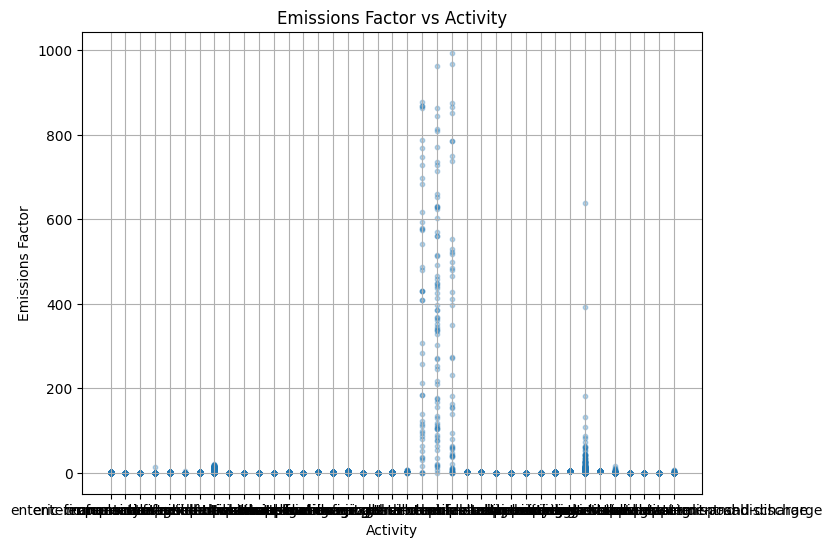

In [34]:


plt.figure(figsize=(8, 6))
plt.scatter(
    df_1["subsector"],
    df_1["emissions_factor"],
    alpha=0.3,
    s=10
)

plt.xlabel("Activity")
plt.ylabel("Emissions Factor")
plt.title("Emissions Factor vs Activity")
plt.grid(True)

plt.show()

<Axes: >

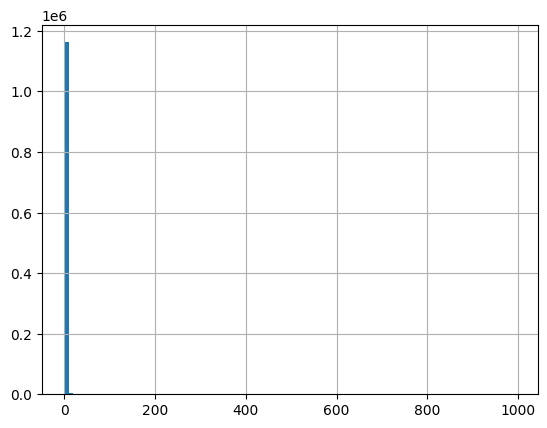

In [35]:
df_1["emissions_factor"].hist(bins=100)

In [36]:
df_1.describe()

,Unnamed: 0,source_id,lat,lon,emissions_quantity,activity,emissions_factor,capacity,capacity_factor
count,1.164928e+06,1.164928e+06,1.091582e+06,1.091582e+06,1.164928e+06,1.164928e+06,1.164928e+06,1.164928e+06,1.164928e+06
mean,7.449880e+05,2.876904e+07,3.174625e+01,-5.640873e-01,3.125417e+03,8.882214e+06,2.950562e-01,4.957898e+07,5.189479e+03
std,5.207679e+05,1.855395e+07,2.390488e+01,6.788769e+01,3.346609e+04,1.153516e+08,5.491162e+00,6.488756e+08,3.448456e+04
min,1.000000e+00,1.100000e+02,-6.481669e+01,-1.798770e+02,7.614000e-09,3.325504e-06,6.512191e-09,4.062664e-06,8.089144e-12
25%,3.357488e+05,3.881821e+06,2.191258e+01,-5.680548e+01,1.018377e+01,7.270800e+01,4.703606e-03,4.400000e+01,9.960000e-01
50%,6.466935e+05,3.848910e+07,4.071239e+01,5.305995e+00,2.924963e+01,2.281500e+02,1.193436e-01,1.050000e+02,9.960000e-01
75%,9.915662e+05,4.545312e+07,4.831003e+01,2.746576e+01,2.805259e+02,1.995086e+04,2.873093e-01,4.850000e+03,1.088853e+01
max,1.817014e+06,5.446292e+07,8.070683e+01,1.799940e+02,5.392744e+06,3.602748e+10,9.934629e+02,1.318983e+11,1.278765e+07


In [37]:
table = (
    df_1.groupby("subsector")["emissions_factor"]
    .agg(
        count="count",
        mean="mean",
        median="median",
        std="std",
        min="min",
        max="max"
    )
    .sort_values("mean", ascending=False)
)

table

,count,mean,median,std,min,max
subsector,,,,,,
other-chemicals,47,360.499590,307.704505,2.944129e+02,8.391178e-02,877.297683
other-manufacturing,74,359.633492,348.035042,2.519845e+02,1.703611e-01,961.642025
other-metals,57,272.111257,137.767877,3.084992e+02,2.841971e-02,993.462906
rice-cultivation,13176,4.713776,2.188322,4.194268e+00,2.802710e-04,21.247065
international-aviation,1342,3.184848,3.184848,8.993675e-16,3.184848e+00,3.184848
domestic-aviation,3698,3.184848,3.184848,2.198560e-15,3.184848e+00,3.184848
aluminum,308,2.289009,2.500000,3.782254e-01,7.230000e-01,2.500000
chemicals,412,2.197451,2.110000,1.328852e+00,3.750000e-01,3.880000
petrochemical-steam-cracking,231,1.761311,1.664039,4.062220e-01,1.200305e+00,3.293701
